# Brazilian E-Commerce Analysis — Olist Dataset
## Phase 2: Exploratory Data Analysis (EDA)
**Author:** Yasser Ramzy  
**Dataset:** [Olist Brazilian E-Commerce — Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Tools:** Python · Pandas · Matplotlib · Seaborn  

### Business Questions We Will Answer
1. How did revenue trend over time?
2. Which product categories drive the most revenue?
3. How does delivery performance vary across Brazil?
4. What factors most influence customer review scores?
5. What does customer buying behavior look like?

In [1]:
# ── Libraries ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# ── Plot style ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# ── Load clean master table ─────────────────────────────────
path = r"C:\Users\yasse\OneDrive\Desktop\data analysis projects\Brazilian-E-Commerce-SQL-POWERBI\Brazilian-Olist-SQL-POWERBI-finished-project\outputs\master_delivered.csv"

df = pd.read_csv(path, parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

print("✅ Data loaded successfully")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Date range: {df['order_purchase_timestamp'].min().date()} → {df['order_purchase_timestamp'].max().date()}")

✅ Data loaded successfully
   Shape: 96,469 rows × 39 columns
   Date range: 2016-10-03 → 2018-08-29


## Analysis 1: Revenue Trend Over Time
We aggregate total revenue by month to identify growth patterns, seasonality, and any anomalies.

In [2]:
# ── Monthly revenue aggregation ─────────────────────────────
monthly = df.groupby(df['order_purchase_timestamp'].dt.to_period('M')).agg(
    revenue      = ('order_total_value', 'sum'),
    orders       = ('order_id',          'nunique'),
    avg_order    = ('order_total_value', 'mean')
).reset_index()

monthly['order_purchase_timestamp'] = monthly['order_purchase_timestamp'].dt.to_timestamp()

# Drop incomplete boundary months (Oct 2016 and Aug 2018 are partial)
monthly = monthly.iloc[1:-1].reset_index(drop=True)

print(f"✅ Monthly data: {len(monthly)} months")
print(monthly[['order_purchase_timestamp', 'revenue', 'orders']].to_string(index=False))

✅ Monthly data: 20 months
order_purchase_timestamp    revenue  orders
              2016-12-01      19.62       1
              2017-01-01  127482.37     750
              2017-02-01  271239.32    1653
              2017-03-01  414330.95    2546
              2017-04-01  390812.40    2303
              2017-05-01  566657.40    3545
              2017-06-01  490050.37    3135
              2017-07-01  566299.08    3872
              2017-08-01  645832.36    4193
              2017-09-01  701077.49    4150
              2017-10-01  751117.01    4478
              2017-11-01 1153229.37    7288
              2017-12-01  843078.29    5513
              2018-01-01 1077887.46    7069
              2018-02-01  966168.41    6555
              2018-03-01 1120598.24    7003
              2018-04-01 1132878.93    6798
              2018-05-01 1128774.52    6749
              2018-06-01 1011448.96    6096
              2018-07-01 1027286.52    6156


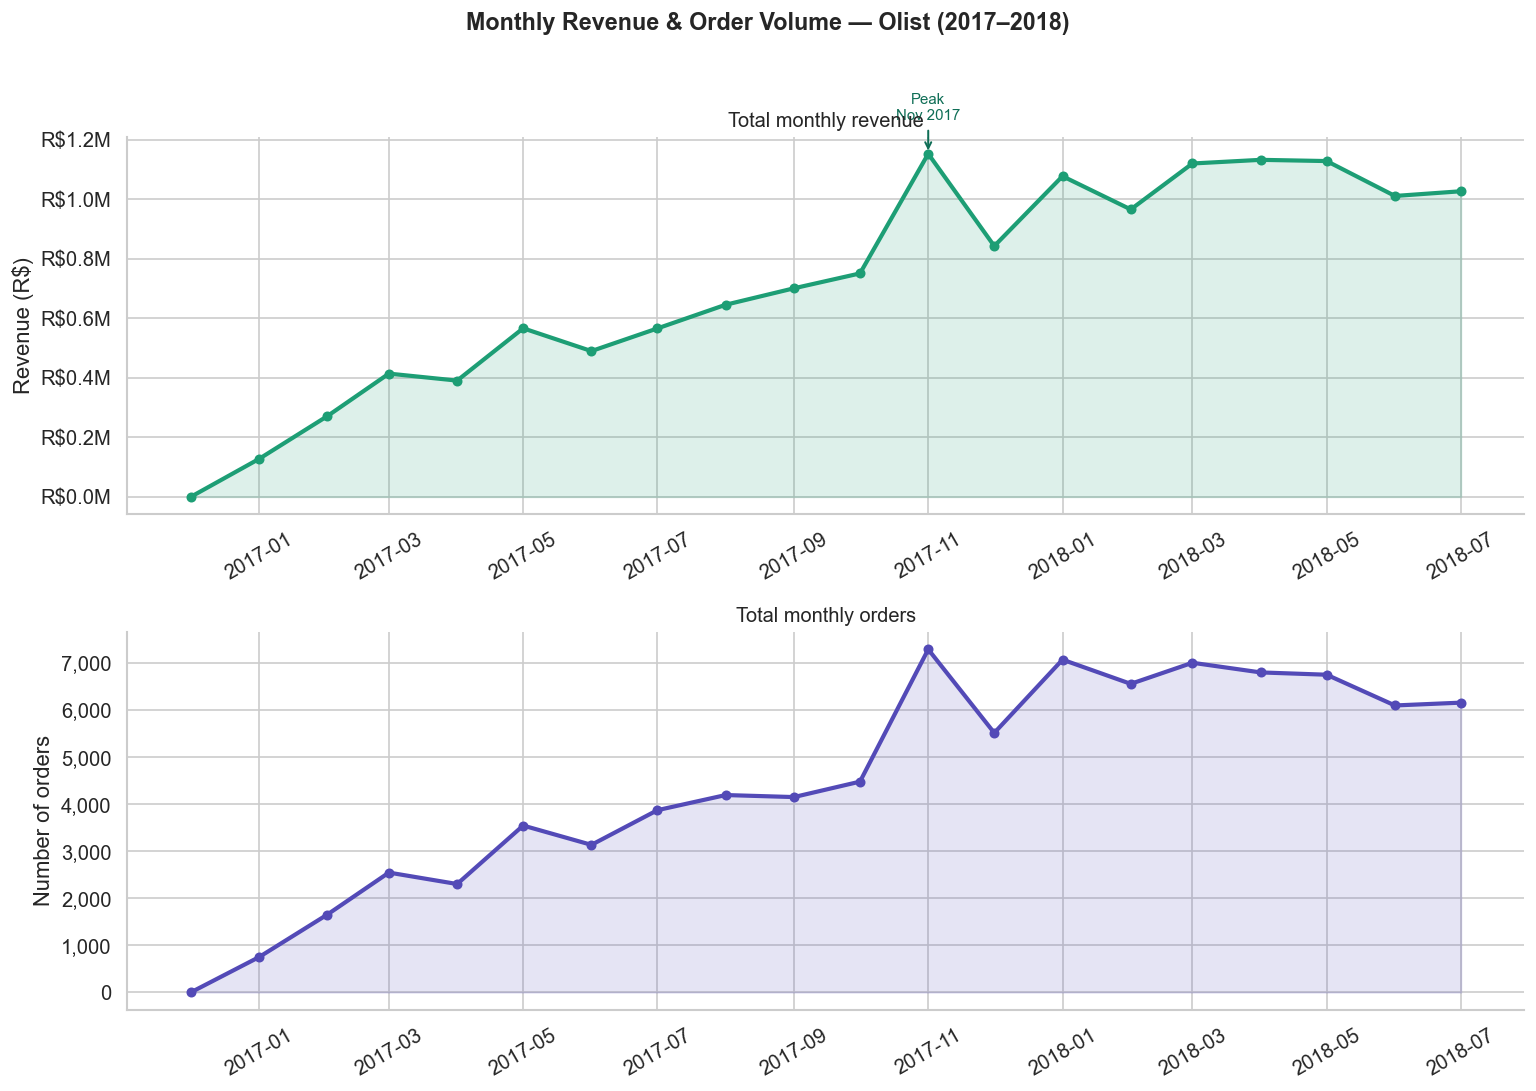

✅ Chart saved


In [3]:
# ── Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle('Monthly Revenue & Order Volume — Olist (2017–2018)',
             fontsize=14, fontweight='bold', y=1.01)

# ── Top: Revenue ────────────────────────────────────────────
ax1 = axes[0]
ax1.fill_between(monthly['order_purchase_timestamp'],
                 monthly['revenue'], alpha=0.15, color='#1D9E75')
ax1.plot(monthly['order_purchase_timestamp'],
         monthly['revenue'], color='#1D9E75', linewidth=2.5, marker='o', markersize=5)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax1.set_title('Total monthly revenue', fontsize=12)
ax1.set_xlabel('')
ax1.set_ylabel('Revenue (R$)')

# Annotate peak month
peak_idx = monthly['revenue'].idxmax()
ax1.annotate(f"Peak\n{monthly.loc[peak_idx, 'order_purchase_timestamp'].strftime('%b %Y')}",
             xy=(monthly.loc[peak_idx, 'order_purchase_timestamp'],
                 monthly.loc[peak_idx, 'revenue']),
             xytext=(0, 20), textcoords='offset points',
             ha='center', fontsize=9, color='#0F6E56',
             arrowprops=dict(arrowstyle='->', color='#0F6E56', lw=1.2))

# ── Bottom: Order volume ─────────────────────────────────────
ax2 = axes[1]
ax2.fill_between(monthly['order_purchase_timestamp'],
                 monthly['orders'], alpha=0.15, color='#534AB7')
ax2.plot(monthly['order_purchase_timestamp'],
         monthly['orders'], color='#534AB7', linewidth=2.5, marker='o', markersize=5)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.set_title('Total monthly orders', fontsize=12)
ax2.set_xlabel('')
ax2.set_ylabel('Number of orders')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save
output_path = r"C:\Users\yasse\OneDrive\Desktop\data analysis projects\Brazilian-E-Commerce-SQL-POWERBI\Brazilian-Olist-SQL-POWERBI-finished-project\outputs"
plt.savefig(os.path.join(output_path, 'chart_01_monthly_revenue.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved")

## Analysis 2: Revenue by Product Category
We identify which product categories drive the most revenue and order volume.

In [4]:
# ── Revenue by category ─────────────────────────────────────
category = df.groupby('product_category_name_english').agg(
    revenue      = ('order_total_value', 'sum'),
    orders       = ('order_id',          'nunique'),
    avg_order    = ('order_total_value', 'mean'),
    avg_review   = ('review_score',      lambda x: x[x>0].mean())
).reset_index()

category = category.sort_values('revenue', ascending=False)
top15 = category.head(15).copy()

print("✅ Top 15 categories by revenue:")
print(top15[['product_category_name_english',
             'revenue', 'orders', 'avg_order']].to_string(index=False))

✅ Top 15 categories by revenue:
product_category_name_english    revenue  orders  avg_order
                health_beauty 1410754.41    8607 163.907797
                watches_gifts 1261539.27    5470 230.628751
               bed_bath_table 1223852.92    9167 133.506373
               sports_leisure 1119060.16    7490 149.407231
        computers_accessories 1030615.59    6500 158.556245
              furniture_decor  884057.80    6213 142.291614
                   housewares  760680.24    5688 133.734219
                   cool_stuff  692902.01    3530 196.289521
                         auto  669221.94    3792 176.482579
                 garden_tools  567542.45    3414 166.239733
                         toys  546339.39    3778 144.610744
                         baby  466203.02    2763 168.730735
                    perfumery  443861.79    3073 144.439242
                    telephony  379433.05    4076  93.089561
             office_furniture  334080.20    1246 268.122151


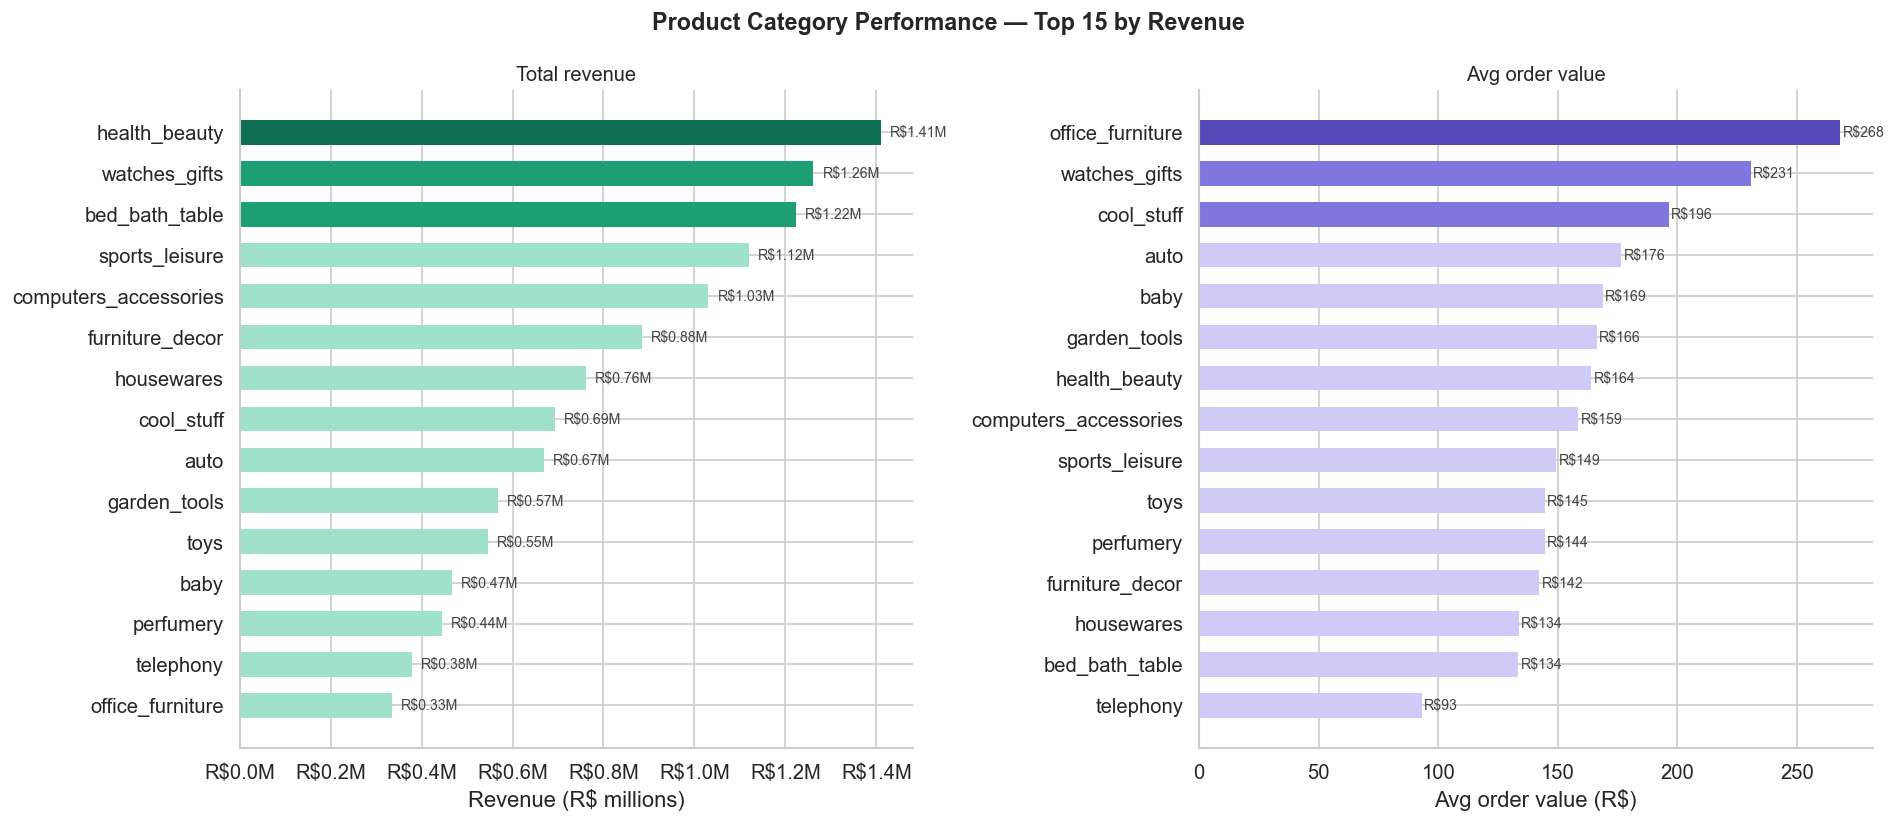

✅ Chart saved


In [5]:
# ── Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Product Category Performance — Top 15 by Revenue',
             fontsize=14, fontweight='bold')

# ── Left: Revenue bar ───────────────────────────────────────
colors_rev = ['#0F6E56' if i == 0 else '#1D9E75' if i < 3 else '#9FE1CB'
              for i in range(15)]

bars = axes[0].barh(top15['product_category_name_english'][::-1],
                    top15['revenue'][::-1] / 1e6,
                    color=colors_rev[::-1], edgecolor='none', height=0.6)

axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
axes[0].set_title('Total revenue', fontsize=12)
axes[0].set_xlabel('Revenue (R$ millions)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Value labels
for bar, val in zip(bars, top15['revenue'][::-1]):
    axes[0].text(val/1e6 + 0.02, bar.get_y() + bar.get_height()/2,
                 f'R${val/1e6:.2f}M', va='center', fontsize=8.5, color='#444441')

# ── Right: Avg order value ──────────────────────────────────
colors_avg = ['#534AB7' if i == 0 else '#7F77DD' if i < 3 else '#CECBF6'
              for i in range(15)]

top15_avg = top15.sort_values('avg_order', ascending=True)
bars2 = axes[1].barh(top15_avg['product_category_name_english'],
                     top15_avg['avg_order'],
                     color=colors_avg[::-1], edgecolor='none', height=0.6)

axes[1].set_title('Avg order value', fontsize=12)
axes[1].set_xlabel('Avg order value (R$)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Value labels
for bar, val in zip(bars2, top15_avg['avg_order']):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'R${val:.0f}', va='center', fontsize=8.5, color='#444441')

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart_02_category_revenue.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved")

## Analysis 3: Delivery Performance
We analyze delivery times and late orders across Brazil, and measure how delivery
performance impacts customer review scores.

In [6]:
# ── Delivery performance overview ───────────────────────────
print("── Delivery time distribution ──────────────────────")
print(df['delivery_days'].describe().round(1))

print("\n── Late orders by state (top 10 worst) ─────────────")
state_delivery = df.groupby('customer_state').agg(
    orders        = ('order_id',        'nunique'),
    avg_days      = ('delivery_days',   'mean'),
    late_rate     = ('is_late',         'mean'),
    avg_review    = ('review_score',    lambda x: x[x>0].mean())
).reset_index()

state_delivery['late_rate_pct'] = (state_delivery['late_rate'] * 100).round(1)
state_delivery['avg_days']      = state_delivery['avg_days'].round(1)
state_delivery['avg_review']    = state_delivery['avg_review'].round(2)

print(state_delivery.sort_values('late_rate', ascending=False)
      [['customer_state','orders','avg_days','late_rate_pct','avg_review']]
      .head(10).to_string(index=False))

print("\n── Late orders by state (top 10 best) ──────────────")
print(state_delivery.sort_values('late_rate', ascending=True)
      [['customer_state','orders','avg_days','late_rate_pct','avg_review']]
      .head(10).to_string(index=False))

── Delivery time distribution ──────────────────────
count    96469.0
mean        12.1
std          9.6
min          0.0
25%          6.0
50%         10.0
75%         15.0
max        209.0
Name: delivery_days, dtype: float64

── Late orders by state (top 10 worst) ─────────────
customer_state  orders  avg_days  late_rate_pct  avg_review
            AL     397      24.0           21.4        3.85
            MA     717      21.1           17.4        3.83
            SE     335      21.0           15.2        3.91
            PI     476      19.0           13.9        3.99
            CE    1279      20.8           13.8        3.94
            RR      41      29.0           12.2        3.90
            BA    3256      18.9           12.2        3.93
            RJ   12350      14.8           12.1        3.97
            PA     946      23.3           11.2        3.91
            ES    1995      15.3           10.7        4.08

── Late orders by state (top 10 best) ──────────────
custome

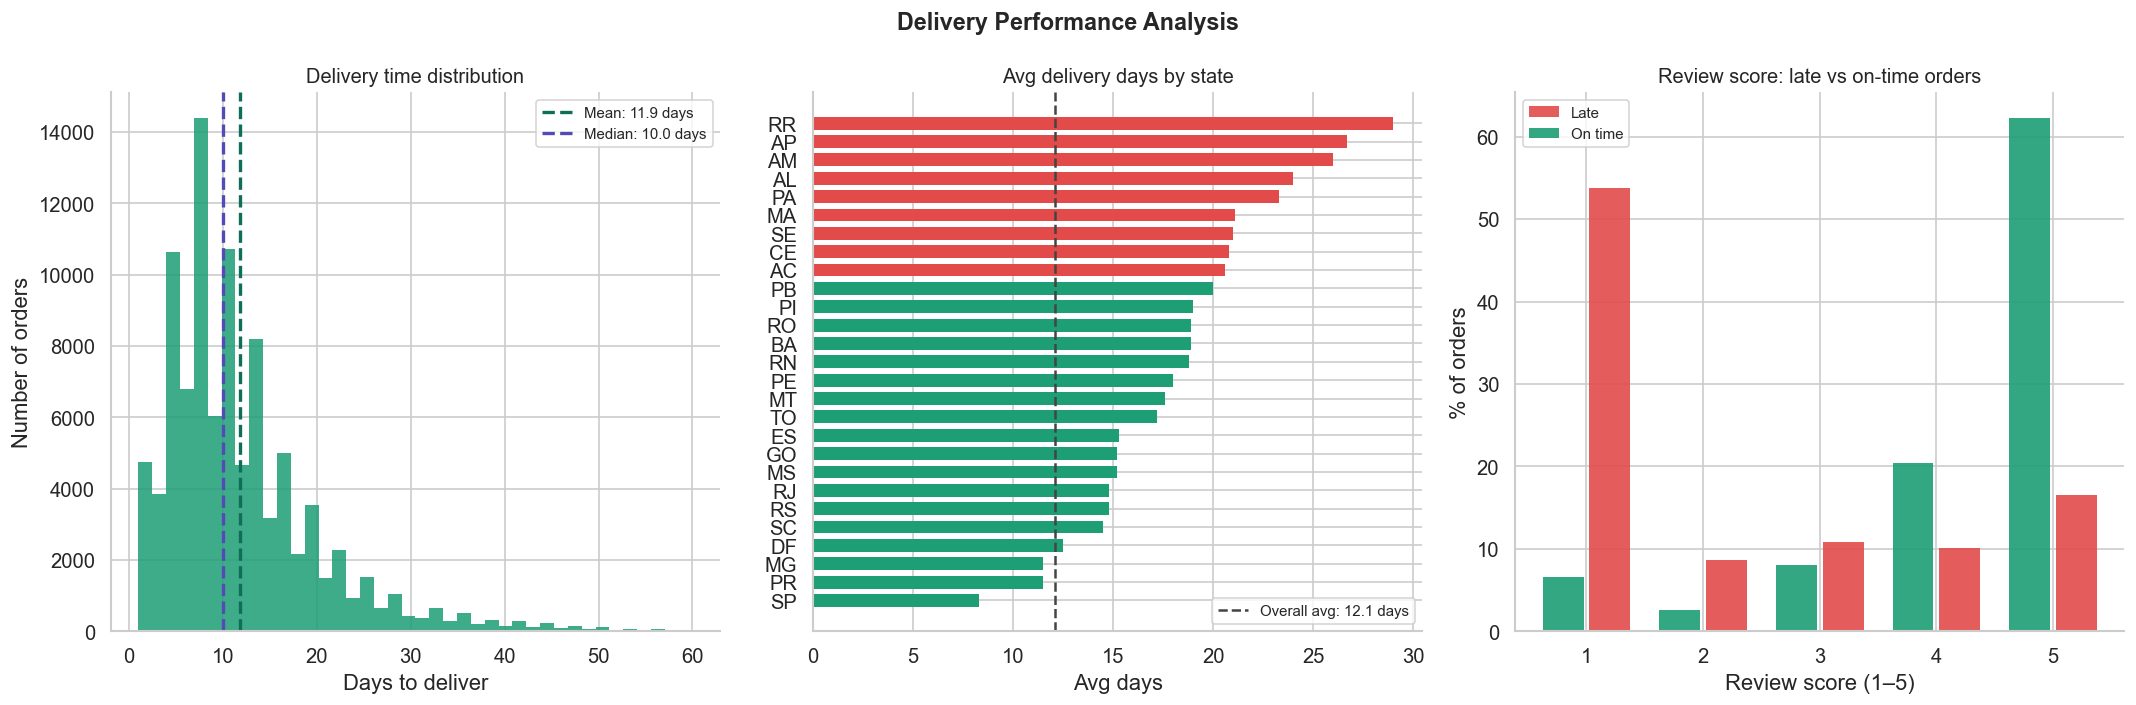

✅ Chart saved


In [7]:
# ── Plot: delivery days distribution + late vs on-time reviews
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Delivery Performance Analysis', fontsize=14, fontweight='bold')

# ── Left: Delivery days histogram ───────────────────────────
delivery_clean = df['delivery_days'].dropna()
delivery_clean = delivery_clean[delivery_clean.between(1, 60)]

axes[0].hist(delivery_clean, bins=40, color='#1D9E75',
             edgecolor='none', alpha=0.85)
axes[0].axvline(delivery_clean.mean(), color='#0F6E56',
                linestyle='--', linewidth=2,
                label=f'Mean: {delivery_clean.mean():.1f} days')
axes[0].axvline(delivery_clean.median(), color='#534AB7',
                linestyle='--', linewidth=2,
                label=f'Median: {delivery_clean.median():.1f} days')
axes[0].set_title('Delivery time distribution', fontsize=12)
axes[0].set_xlabel('Days to deliver')
axes[0].set_ylabel('Number of orders')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Middle: Avg delivery days by state ──────────────────────
state_plot = state_delivery.sort_values('avg_days', ascending=True)
colors_state = ['#E24B4A' if x > 20 else '#1D9E75'
                for x in state_plot['avg_days']]

axes[1].barh(state_plot['customer_state'], state_plot['avg_days'],
             color=colors_state, edgecolor='none', height=0.7)
axes[1].axvline(12.1, color='#444441', linestyle='--',
                linewidth=1.5, label='Overall avg: 12.1 days')
axes[1].set_title('Avg delivery days by state', fontsize=12)
axes[1].set_xlabel('Avg days')
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# ── Right: Review score — late vs on time ───────────────────
review_comp = df[df['review_score'] > 0].copy()
late_reviews   = review_comp[review_comp['is_late'] == 1]['review_score']
ontime_reviews = review_comp[review_comp['is_late'] == 0]['review_score']

score_data = pd.DataFrame({
    'score': list(range(1, 6)) * 2,
    'pct':   [
        *[(late_reviews == s).mean() * 100   for s in range(1, 6)],
        *[(ontime_reviews == s).mean() * 100 for s in range(1, 6)]
    ],
    'group': ['Late'] * 5 + ['On time'] * 5
})

colors_group = {'Late': '#E24B4A', 'On time': '#1D9E75'}
for group, grp_data in score_data.groupby('group'):
    axes[2].bar(grp_data['score'] + (0.2 if group == 'Late' else -0.2),
                grp_data['pct'], width=0.35,
                color=colors_group[group], label=group,
                edgecolor='none', alpha=0.9)

axes[2].set_title('Review score: late vs on-time orders', fontsize=12)
axes[2].set_xlabel('Review score (1–5)')
axes[2].set_ylabel('% of orders')
axes[2].set_xticks(range(1, 6))
axes[2].legend(fontsize=9)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart_03_delivery_performance.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved")

## Analysis 4: What Drives Customer Review Scores?
We investigate the relationship between delivery performance, order value,
and customer satisfaction scores.

In [8]:
# ── Review score analysis ────────────────────────────────────
reviews = df[df['review_score'] > 0].copy()

print("── Review score distribution ───────────────────────")
score_dist = reviews['review_score'].value_counts().sort_index()
score_pct  = (score_dist / len(reviews) * 100).round(1)
for score, pct in score_pct.items():
    bar = '█' * int(pct / 2)
    print(f"  {score}★  {bar:<25} {pct}%")

print(f"\n── Avg review by delivery bucket ───────────────────")
reviews['delivery_bucket'] = pd.cut(
    reviews['delivery_days'],
    bins   = [0, 5, 10, 15, 20, 30, 999],
    labels = ['0–5d', '6–10d', '11–15d', '16–20d', '21–30d', '30d+']
)
bucket_review = reviews.groupby('delivery_bucket', observed=True).agg(
    orders     = ('order_id',      'count'),
    avg_review = ('review_score',  'mean')
).reset_index()
bucket_review['avg_review'] = bucket_review['avg_review'].round(2)
print(bucket_review.to_string(index=False))

print(f"\n── Avg review: late vs on-time ─────────────────────")
late_avg   = reviews[reviews['is_late']==1]['review_score'].mean()
ontime_avg = reviews[reviews['is_late']==0]['review_score'].mean()
print(f"  On-time orders : {ontime_avg:.2f} / 5")
print(f"  Late orders    : {late_avg:.2f} / 5")
print(f"  Difference     : {ontime_avg - late_avg:.2f} points")

── Review score distribution ───────────────────────
  1.0★  ████                      9.8%
  2.0★  █                         3.0%
  3.0★  ████                      8.3%
  4.0★  █████████                 19.7%
  5.0★  █████████████████████████████ 59.2%

── Avg review by delivery bucket ───────────────────
delivery_bucket  orders  avg_review
           0–5d   19141        4.43
          6–10d   32685        4.35
         11–15d   21037        4.25
         16–20d   10636        4.09
         21–30d    8305        3.58
           30d+    4006        2.17

── Avg review: late vs on-time ─────────────────────
  On-time orders : 4.29 / 5
  Late orders    : 2.27 / 5
  Difference     : 2.02 points


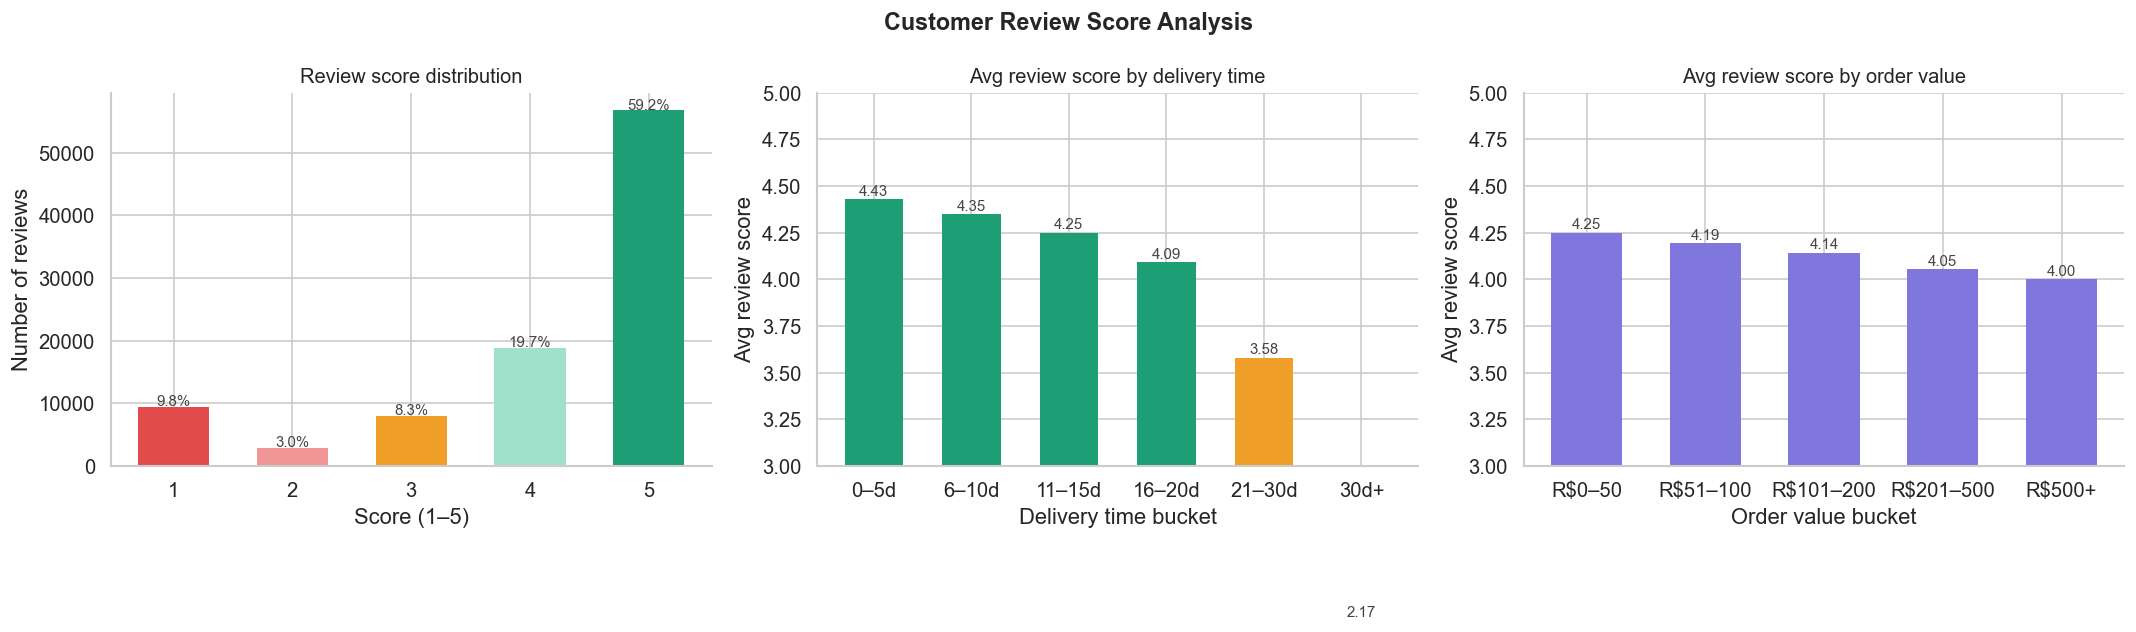

✅ Chart saved


In [9]:
# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Customer Review Score Analysis', fontsize=14, fontweight='bold')

# ── Left: Score distribution ─────────────────────────────────
score_counts = reviews['review_score'].value_counts().sort_index()
bar_colors   = ['#E24B4A','#F09595','#EF9F27','#9FE1CB','#1D9E75']
axes[0].bar(score_counts.index, score_counts.values,
            color=bar_colors, edgecolor='none', width=0.6)
axes[0].set_title('Review score distribution', fontsize=12)
axes[0].set_xlabel('Score (1–5)')
axes[0].set_ylabel('Number of reviews')
axes[0].set_xticks(range(1, 6))
for i, (score, count) in enumerate(score_counts.items()):
    axes[0].text(score, count + 200,
                 f'{count/len(reviews)*100:.1f}%',
                 ha='center', fontsize=9, color='#444441')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Middle: Avg review by delivery bucket ────────────────────
bucket_colors = ['#1D9E75' if v >= 4.0 else '#EF9F27' if v >= 3.5
                 else '#E24B4A' for v in bucket_review['avg_review']]
axes[1].bar(bucket_review['delivery_bucket'].astype(str),
            bucket_review['avg_review'],
            color=bucket_colors, edgecolor='none', width=0.6)
axes[1].set_ylim(3.0, 5.0)
axes[1].set_title('Avg review score by delivery time', fontsize=12)
axes[1].set_xlabel('Delivery time bucket')
axes[1].set_ylabel('Avg review score')
for i, row in bucket_review.iterrows():
    axes[1].text(i, row['avg_review'] + 0.02,
                 f"{row['avg_review']:.2f}",
                 ha='center', fontsize=9, color='#444441')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# ── Right: Avg review by order value bucket ──────────────────
reviews['value_bucket'] = pd.cut(
    reviews['order_total_value'],
    bins   = [0, 50, 100, 200, 500, 99999],
    labels = ['R$0–50', 'R$51–100', 'R$101–200', 'R$201–500', 'R$500+']
)
value_review = reviews.groupby('value_bucket', observed=True).agg(
    avg_review = ('review_score', 'mean')
).reset_index()

value_colors = ['#7F77DD','#7F77DD','#7F77DD','#7F77DD','#7F77DD']
axes[2].bar(value_review['value_bucket'].astype(str),
            value_review['avg_review'],
            color=value_colors, edgecolor='none', width=0.6)
axes[2].set_ylim(3.0, 5.0)
axes[2].set_title('Avg review score by order value', fontsize=12)
axes[2].set_xlabel('Order value bucket')
axes[2].set_ylabel('Avg review score')
for i, row in value_review.iterrows():
    axes[2].text(i, row['avg_review'] + 0.02,
                 f"{row['avg_review']:.2f}",
                 ha='center', fontsize=9, color='#444441')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart_04_review_analysis.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved")

## Analysis 5: Customer Buying Behavior
We analyze purchasing patterns by day of week, month, and repeat purchase behavior
to understand how customers interact with the platform.

In [10]:
# ── Buying behavior ──────────────────────────────────────────

print("── Orders by day of week ───────────────────────────")
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('purchase_day_of_week')['order_id'].nunique().reindex(dow_order)
for day, count in dow.items():
    bar = '█' * int(count / 200)
    print(f"  {day:<12} {bar:<40} {count:,}")

print("\n── Orders by month ─────────────────────────────────")
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
month = df.groupby('purchase_month_name')['order_id'].nunique().reindex(month_order)
for m, count in month.items():
    bar = '█' * int(count / 300)
    print(f"  {m:<5} {bar:<35} {count:,}")

print("\n── Repeat customer analysis ────────────────────────")
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique()
repeat = customer_orders[customer_orders > 1]
single = customer_orders[customer_orders == 1]
print(f"  One-time customers  : {len(single):,}  ({len(single)/len(customer_orders)*100:.1f}%)")
print(f"  Repeat customers    : {len(repeat):,}  ({len(repeat)/len(customer_orders)*100:.1f}%)")
print(f"  Max orders by 1 customer: {customer_orders.max()}")
print(f"  Avg orders per repeat customer: {repeat.mean():.2f}")

── Orders by day of week ───────────────────────────
  Monday       ██████████████████████████████████████████████████████████████████████████████ 15,701
  Tuesday      █████████████████████████████████████████████████████████████████████████████ 15,502
  Wednesday    ███████████████████████████████████████████████████████████████████████████ 15,074
  Thursday     ███████████████████████████████████████████████████████████████████████ 14,321
  Friday       ████████████████████████████████████████████████████████████████████ 13,684
  Saturday     ████████████████████████████████████████████████████ 10,555
  Sunday       ██████████████████████████████████████████████████████████ 11,632

── Orders by month ─────────────────────────────────
  Jan   ██████████████████████████          7,819
  Feb   ███████████████████████████         8,208
  Mar   ███████████████████████████████     9,549
  Apr   ██████████████████████████████      9,101
  May   ██████████████████████████████████  10,294
  

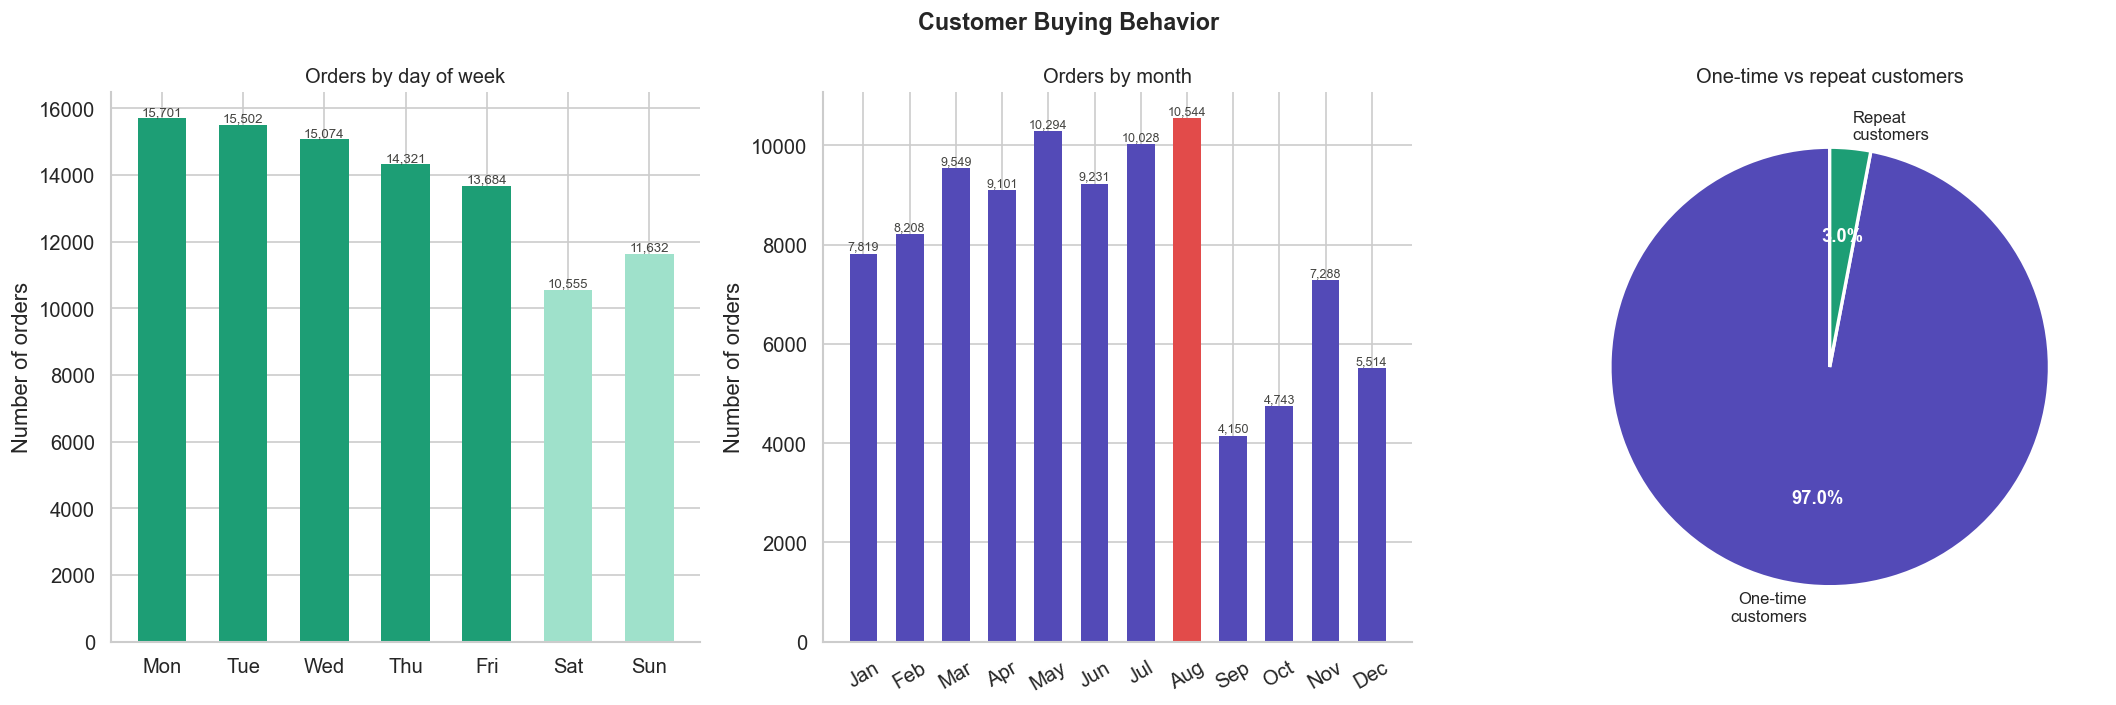

✅ Chart saved


In [11]:
# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Customer Buying Behavior', fontsize=14, fontweight='bold')

# ── Left: Orders by day of week ──────────────────────────────
dow_colors = ['#1D9E75' if d not in ['Saturday','Sunday']
              else '#9FE1CB' for d in dow_order]
axes[0].bar(range(7), dow.values, color=dow_colors,
            edgecolor='none', width=0.6)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[0].set_title('Orders by day of week', fontsize=12)
axes[0].set_ylabel('Number of orders')
for i, val in enumerate(dow.values):
    axes[0].text(i, val + 100, f'{val:,}',
                 ha='center', fontsize=8, color='#444441')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Middle: Orders by month ───────────────────────────────────
month_vals = month.values
month_colors = ['#E24B4A' if v == month_vals.max()
                else '#534AB7' for v in month_vals]
axes[1].bar(range(12), month_vals, color=month_colors,
            edgecolor='none', width=0.6)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_order, rotation=30)
axes[1].set_title('Orders by month', fontsize=12)
axes[1].set_ylabel('Number of orders')
for i, val in enumerate(month_vals):
    axes[1].text(i, val + 80, f'{val:,}',
                 ha='center', fontsize=7.5, color='#444441')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# ── Right: One-time vs repeat customers ──────────────────────
labels = ['One-time\ncustomers', 'Repeat\ncustomers']
sizes  = [len(single), len(repeat)]
colors = ['#534AB7', '#1D9E75']
wedges, texts, autotexts = axes[2].pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')
axes[2].set_title('One-time vs repeat customers', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart_05_buying_behavior.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved")

## Analysis 6: Seller Performance
We identify top performing sellers and analyze the concentration of revenue
across the seller base.

In [12]:
# ── Seller performance ───────────────────────────────────────
seller_perf = df.groupby('seller_id').agg(
    revenue    = ('order_total_value', 'sum'),
    orders     = ('order_id',          'nunique'),
    avg_review = ('review_score',      lambda x: x[x>0].mean()),
    avg_days   = ('delivery_days',     'mean'),
    late_rate  = ('is_late',           'mean'),
    states     = ('customer_state',    'nunique')
).reset_index()

seller_perf = seller_perf.sort_values('revenue', ascending=False).reset_index(drop=True)

print("── Top 10 sellers by revenue ───────────────────────")
print(seller_perf[['seller_id','revenue','orders',
                   'avg_review','late_rate']]
      .head(10)
      .assign(seller_id = lambda x: x['seller_id'].str[:8] + '...',
              revenue   = lambda x: x['revenue'].round(0),
              avg_review= lambda x: x['avg_review'].round(2),
              late_rate = lambda x: (x['late_rate']*100).round(1))
      .to_string(index=False))

print("\n── Revenue concentration (Pareto analysis) ─────────")
total_rev   = seller_perf['revenue'].sum()
top10_rev   = seller_perf.head(10)['revenue'].sum()
top50_rev   = seller_perf.head(50)['revenue'].sum()
top100_rev  = seller_perf.head(100)['revenue'].sum()
total_sellers = len(seller_perf)

print(f"  Total sellers       : {total_sellers:,}")
print(f"  Top 10  sellers → {top10_rev/total_rev*100:.1f}% of revenue")
print(f"  Top 50  sellers → {top50_rev/total_rev*100:.1f}% of revenue")
print(f"  Top 100 sellers → {top100_rev/total_rev*100:.1f}% of revenue")

── Top 10 sellers by revenue ───────────────────────
  seller_id  revenue  orders  avg_review  late_rate
4869f7a5... 247938.0    1117        4.16       10.6
7c67e144... 235937.0     966        3.50        9.2
4a3ca931... 233449.0    1726        3.89       10.0
53243585... 230797.0     348        4.19        3.4
fa1c13f2... 200044.0     571        4.39        9.3
da8622b1... 185793.0    1295        4.19        6.7
1025f0e2... 172778.0     898        4.02        8.0
7e93a43e... 171567.0     318        4.38        4.7
7a67c85e... 161274.0    1135        4.30        5.3
955fee92... 156714.0    1255        4.21        6.1

── Revenue concentration (Pareto analysis) ─────────
  Total sellers       : 2,960
  Top 10  sellers → 12.9% of revenue
  Top 50  sellers → 32.6% of revenue
  Top 100 sellers → 44.8% of revenue


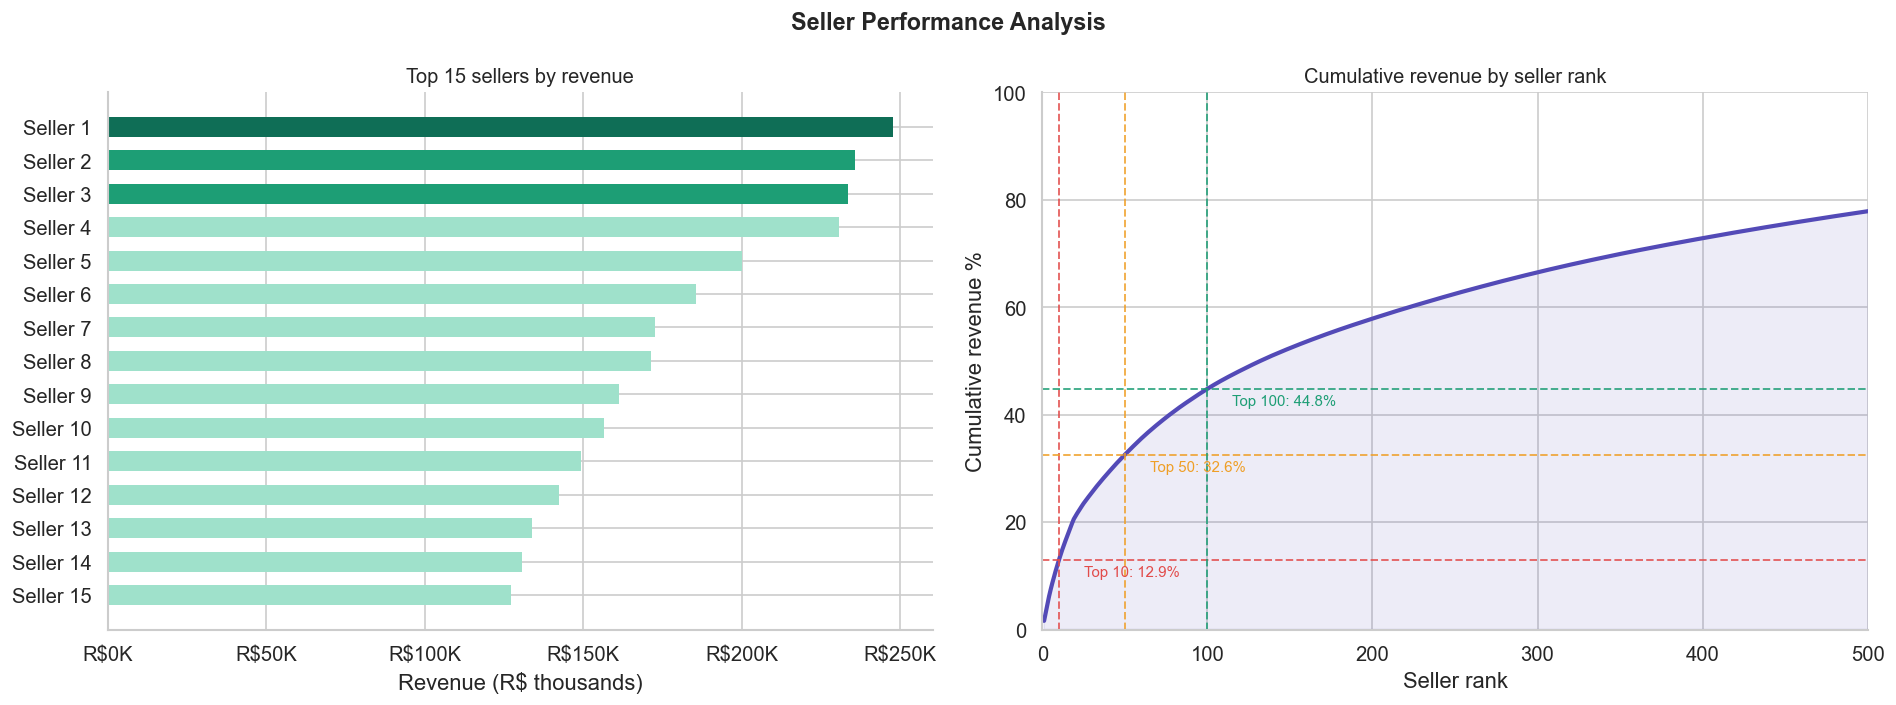

✅ Chart saved


In [13]:
# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Seller Performance Analysis', fontsize=14, fontweight='bold')

# ── Left: Top 15 sellers by revenue ──────────────────────────
top15_sellers = seller_perf.head(15).copy()
top15_sellers['seller_short'] = ['Seller ' + str(i+1)
                                  for i in range(15)]
bar_colors = ['#0F6E56' if i == 0 else '#1D9E75' if i < 3
              else '#9FE1CB' for i in range(15)]

axes[0].barh(top15_sellers['seller_short'][::-1],
             top15_sellers['revenue'][::-1] / 1e3,
             color=bar_colors[::-1], edgecolor='none', height=0.6)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:.0f}K'))
axes[0].set_title('Top 15 sellers by revenue', fontsize=12)
axes[0].set_xlabel('Revenue (R$ thousands)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Right: Pareto — cumulative revenue % ─────────────────────
seller_perf['cumulative_rev_pct'] = (
    seller_perf['revenue'].cumsum() / total_rev * 100
)
seller_perf['seller_rank'] = range(1, len(seller_perf) + 1)

axes[1].plot(seller_perf['seller_rank'],
             seller_perf['cumulative_rev_pct'],
             color='#534AB7', linewidth=2.5)
axes[1].fill_between(seller_perf['seller_rank'],
                     seller_perf['cumulative_rev_pct'],
                     alpha=0.1, color='#534AB7')

# Mark key thresholds
for n, color in [(10, '#E24B4A'), (50, '#EF9F27'), (100, '#1D9E75')]:
    pct = seller_perf.iloc[n-1]['cumulative_rev_pct']
    axes[1].axvline(n, color=color, linestyle='--',
                    linewidth=1.2, alpha=0.8)
    axes[1].axhline(pct, color=color, linestyle='--',
                    linewidth=1.2, alpha=0.8)
    axes[1].text(n + 15, pct - 3,
                 f'Top {n}: {pct:.1f}%',
                 color=color, fontsize=9)

axes[1].set_title('Cumulative revenue by seller rank', fontsize=12)
axes[1].set_xlabel('Seller rank')
axes[1].set_ylabel('Cumulative revenue %')
axes[1].set_xlim(0, 500)
axes[1].set_ylim(0, 100)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart_06_seller_performance.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved")

## EDA Summary — Key Business Insights

### 1. Strong revenue growth
Revenue grew 9x from Jan 2017 to Nov 2017, stabilizing at ~R$1M/month in 2018.
November 2017 peak confirms Black Friday as the strongest sales event.

### 2. Health & beauty leads revenue
Top category by total revenue (R$1.4M) but office furniture has the highest
avg order value (R$268) — high volume vs high value trade-off across categories.

### 3. Delivery time directly drives satisfaction
On-time orders average 4.29/5 stars. Late orders average 2.27/5 — a 2.02 point
drop. Orders taking 30+ days average just 2.17/5. Delivery is the #1 satisfaction driver.

### 4. Northern states struggle with delivery
AL, MA, SE have the worst late rates (15–21%) and lowest review scores.
SP and PR have the best performance — geography is a major operational challenge.

### 5. Severe customer retention problem
97% of customers never returned after their first purchase. Only 3% are repeat buyers.
This is the biggest growth opportunity for the business.

### 6. Healthy seller diversity
Unlike typical marketplaces, revenue is spread across many sellers.
Top 10 sellers = only 12.9% of revenue — low concentration risk.

**Next:** Phase 3 — SQL Business Analysis

In [14]:
# ── Save key metrics for reference in later phases ───────────
summary = {
    'total_orders'        : int(df['order_id'].nunique()),
    'total_revenue'       : round(df['order_total_value'].sum(), 2),
    'avg_order_value'     : round(df['order_total_value'].mean(), 2),
    'avg_delivery_days'   : round(df['delivery_days'].mean(), 1),
    'late_order_pct'      : round(df['is_late'].mean() * 100, 1),
    'avg_review_score'    : round(df[df['review_score']>0]['review_score'].mean(), 2),
    'repeat_customer_pct' : round(len(repeat) / len(customer_orders) * 100, 1),
    'top10_seller_rev_pct': round(top10_rev / total_rev * 100, 1),
    'unique_customers'    : int(df['customer_unique_id'].nunique()),
    'unique_sellers'      : int(df['seller_id'].nunique()),
    'unique_categories'   : int(df['product_category_name_english'].nunique())
}

import json
with open(os.path.join(output_path, 'eda_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print("✅ EDA complete! All charts and summary saved.")
print(f"\n📊 Charts saved to outputs/:")
charts = ['chart_01_monthly_revenue.png',
          'chart_02_category_revenue.png',
          'chart_03_delivery_performance.png',
          'chart_04_review_analysis.png',
          'chart_05_buying_behavior.png',
          'chart_06_seller_performance.png']
for c in charts:
    print(f"   • {c}")
print(f"\n📋 Summary saved: eda_summary.json")

✅ EDA complete! All charts and summary saved.

📊 Charts saved to outputs/:
   • chart_01_monthly_revenue.png
   • chart_02_category_revenue.png
   • chart_03_delivery_performance.png
   • chart_04_review_analysis.png
   • chart_05_buying_behavior.png
   • chart_06_seller_performance.png

📋 Summary saved: eda_summary.json
